## AESTETIK with simulated spatial transcritpomics data

In this notebook we apply AESTETIK on simulated spatial transcriptomics data.

You can find the code for generating spatial transcriptomics data [here](https://github.com/ratschlab/simulate_spatial_transcriptomics_tool). https://github.com/ratschlab/simulate_spatial_transcriptomics_tool

In summary:

> We adapted the simulation approach suggested in [5] by introducing spatial structure in the experiment. Briefly, relying on simulated ground truth labels, we simulate transcriptomics and morphology modalities, allowing partial observation of true clusters within each modality individually. However, combining both modalities enables the identification of all clusters. Spatial coordinates are incorporated by sorting the ground truth in spatial space.

Please refer to our original publication for more information and examples.

Now, we will load the data using scanpy, perform clustering and visualize the results.

In [1]:
from pathlib import Path

REPO_ROOT = Path.cwd() if (Path.cwd() / "test_data").is_dir() else Path.cwd().parent
TEST_DATA = REPO_ROOT / "test_data"


In [2]:
from sklearn.cluster import KMeans
from aestetik import AESTETIK
import squidpy as sq
import scanpy as sc
import numpy as np

/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
adata = sc.read(str(TEST_DATA / "A.h5ad"))
adata


AnnData object with n_obs × n_vars = 1000 × 500
    obs: 'ground_truth', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'Barcode'
    uns: 'spatial'
    obsm: 'X_pca', 'image', 'spatial'

In [4]:
adata.obsm["X_pca"].shape

(1000, 15)

In [5]:
adata.obsm["image"].shape

(1000, 15)

In [6]:
adata.obsm["combined"] = np.concatenate((adata.obsm["X_pca"], adata.obsm["image"]), axis=1)
adata.obsm["combined"].shape

(1000, 30)

Data explanation:
- `X_pca` contains the top 15 PCs computed on the "expression" matrix
- `image` contains the top 15 PCs computed on the "image features"
- `x_array`, `y_array`, `x_pixel`, `y_pixel` are the coordinates in array and pixel space.

### Clustering

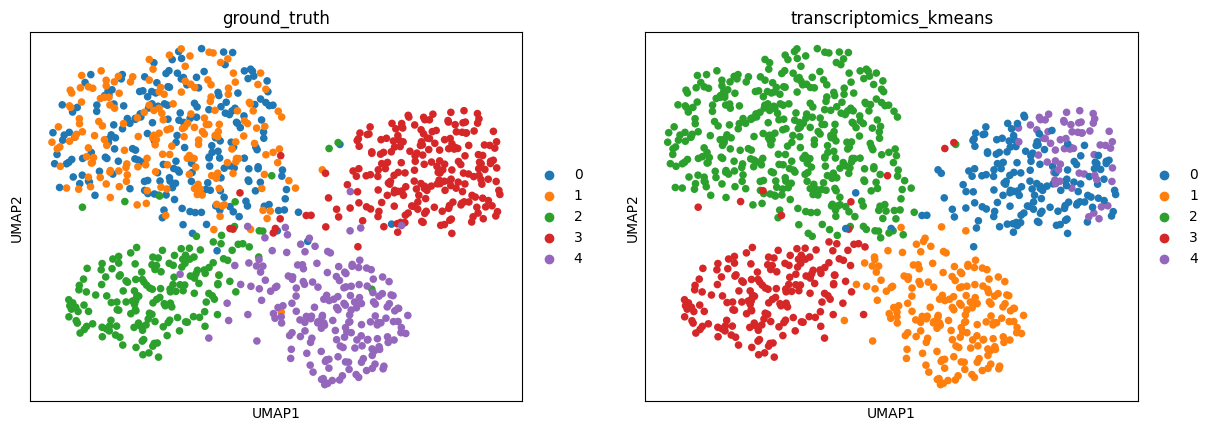

In [7]:
#based only on transcriptomics
sc.pp.neighbors(adata, use_rep="X_pca")
sc.tl.umap(adata)

adata.obs["transcriptomics_kmeans"] = KMeans(5).fit_predict(adata.obsm["X_pca"]).astype(str)
sc.pl.umap(adata, color=["ground_truth", 
                         "transcriptomics_kmeans"])

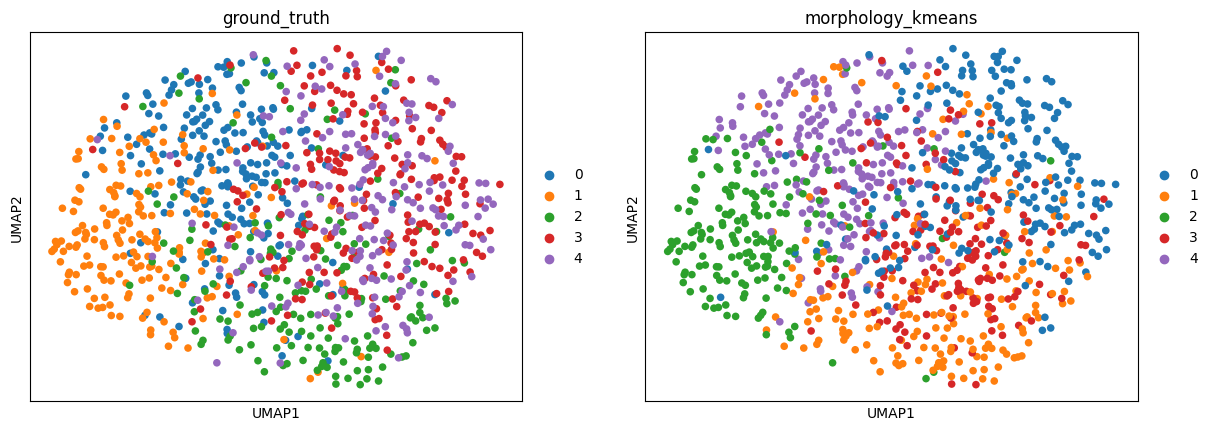

In [8]:
#based only on morphology
sc.pp.neighbors(adata, use_rep="image")
sc.tl.umap(adata)

adata.obs["morphology_kmeans"] = KMeans(5).fit_predict(adata.obsm["image"]).astype(str)
sc.pl.umap(adata, color=["ground_truth", 
                         "morphology_kmeans"])

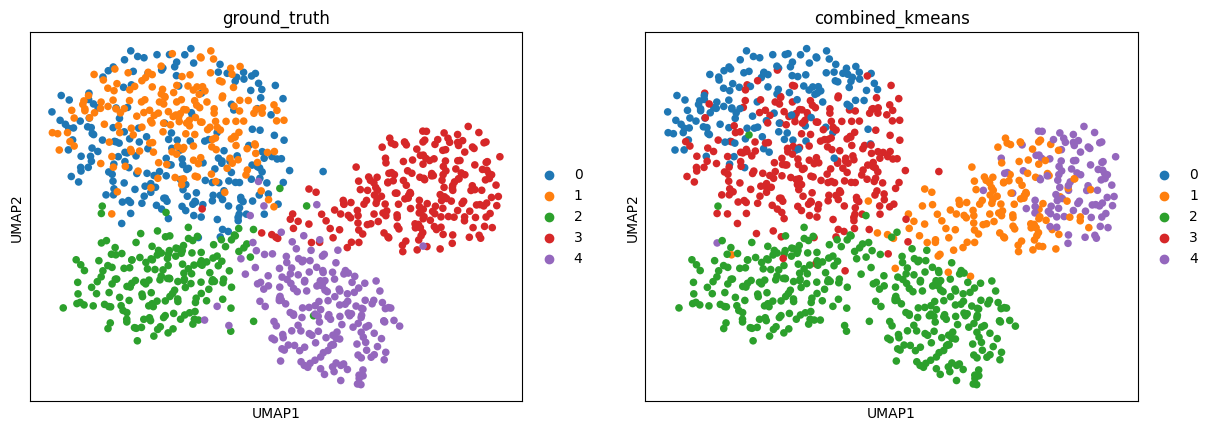

In [9]:
#based only on combined
sc.pp.neighbors(adata, use_rep="combined")
sc.tl.umap(adata)

adata.obs["combined_kmeans"] = KMeans(5).fit_predict(adata.obsm["combined"]).astype(str)
sc.pl.umap(adata, color=["ground_truth", 
                         "combined_kmeans"])

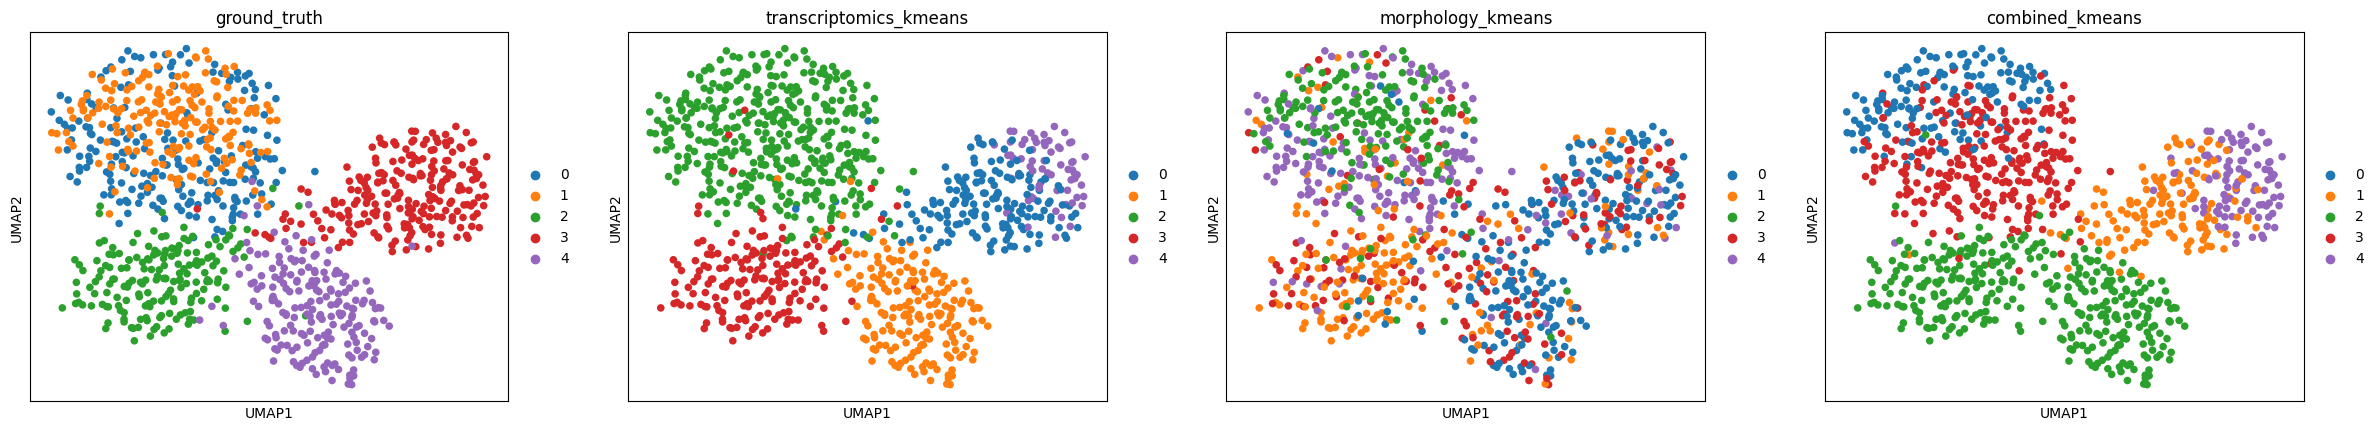

In [10]:
sc.pl.umap(adata, color=["ground_truth", 
                         "transcriptomics_kmeans",
                         "morphology_kmeans",
                         "combined_kmeans"])

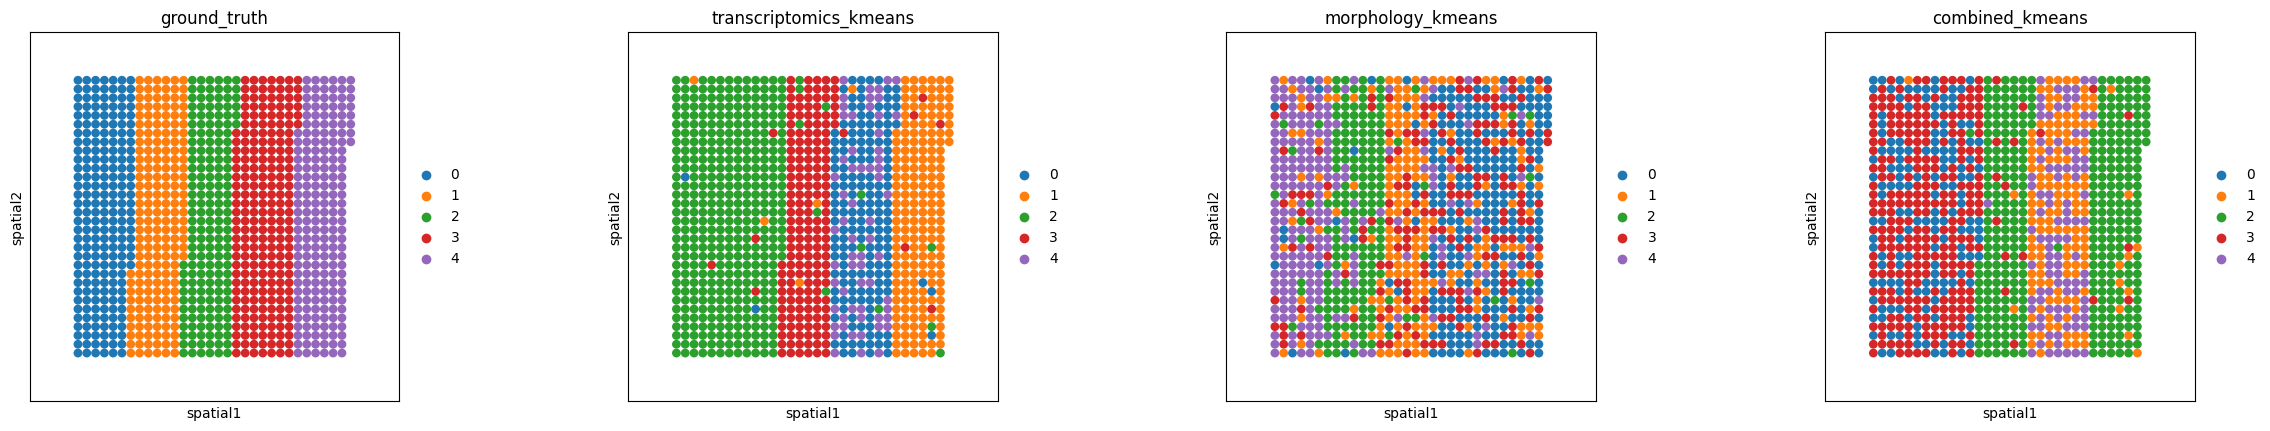

In [11]:
sq.pl.spatial_scatter(adata, color=["ground_truth", 
                         "transcriptomics_kmeans",
                         "morphology_kmeans",
                         "combined_kmeans"], 
                      size=0.5)

### Now, we apply AESTETIK. Please find more infromation about AESTETIK [here](https://github.com/ratschlab/aestetik).

In [12]:
# we set the transcriptomics modality
adata.obsm["X_pca_transcriptomics"] = adata.obsm["X_pca"][:,0:15]
# we set the morphology modality
adata.obsm["X_pca_morphology"] = adata.obsm["image"][:,0:15]

In [13]:
parameters =    {'morphology_weight': 1.5,
                 'refine_cluster': True,
                 'window_size': 3,
                 'clustering_method': "kmeans"
                }
parameters

{'morphology_weight': 1.5,
 'refine_cluster': True,
 'window_size': 3,
 'clustering_method': 'kmeans'}

In [14]:
model = AESTETIK(nCluster=adata.obs.ground_truth.unique().size,
                 **parameters)

[rank: 0] Seed set to 2023


In [15]:
model.fit_predict(adata)

/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /cluster/home/knonchev/miniconda3/envs/aestetik-test ...
GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

`Trainer.fit` stopped: `max_epochs=100` reached.


/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /cluster/home/knonchev/miniconda3/envs/aestetik-test ...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/cluster/home/knonchev/miniconda3/envs/aestetik-test/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


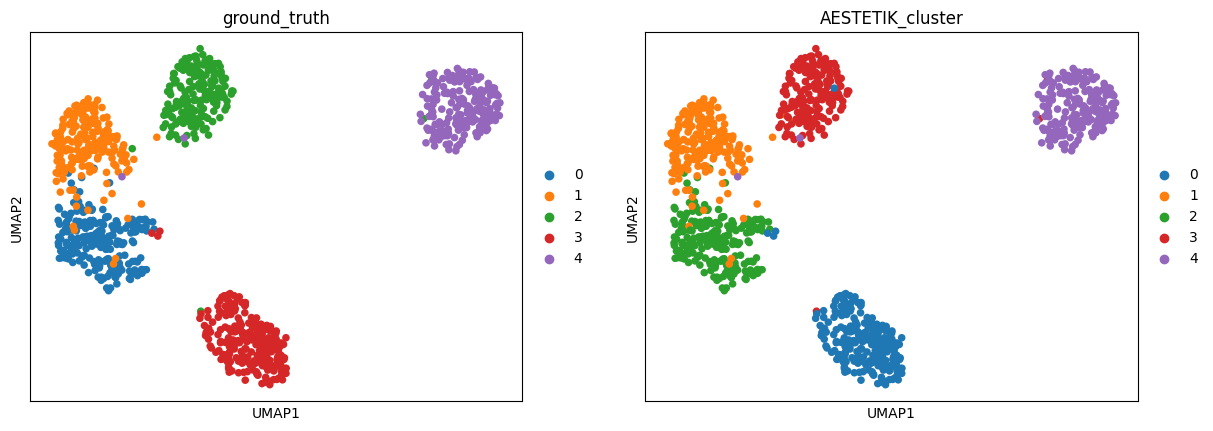

In [16]:
#based on AESTETIK representation
sc.pp.neighbors(adata, use_rep="AESTETIK")
sc.tl.umap(adata)

sc.pl.umap(adata, color=["ground_truth", 
                         "AESTETIK_cluster"])

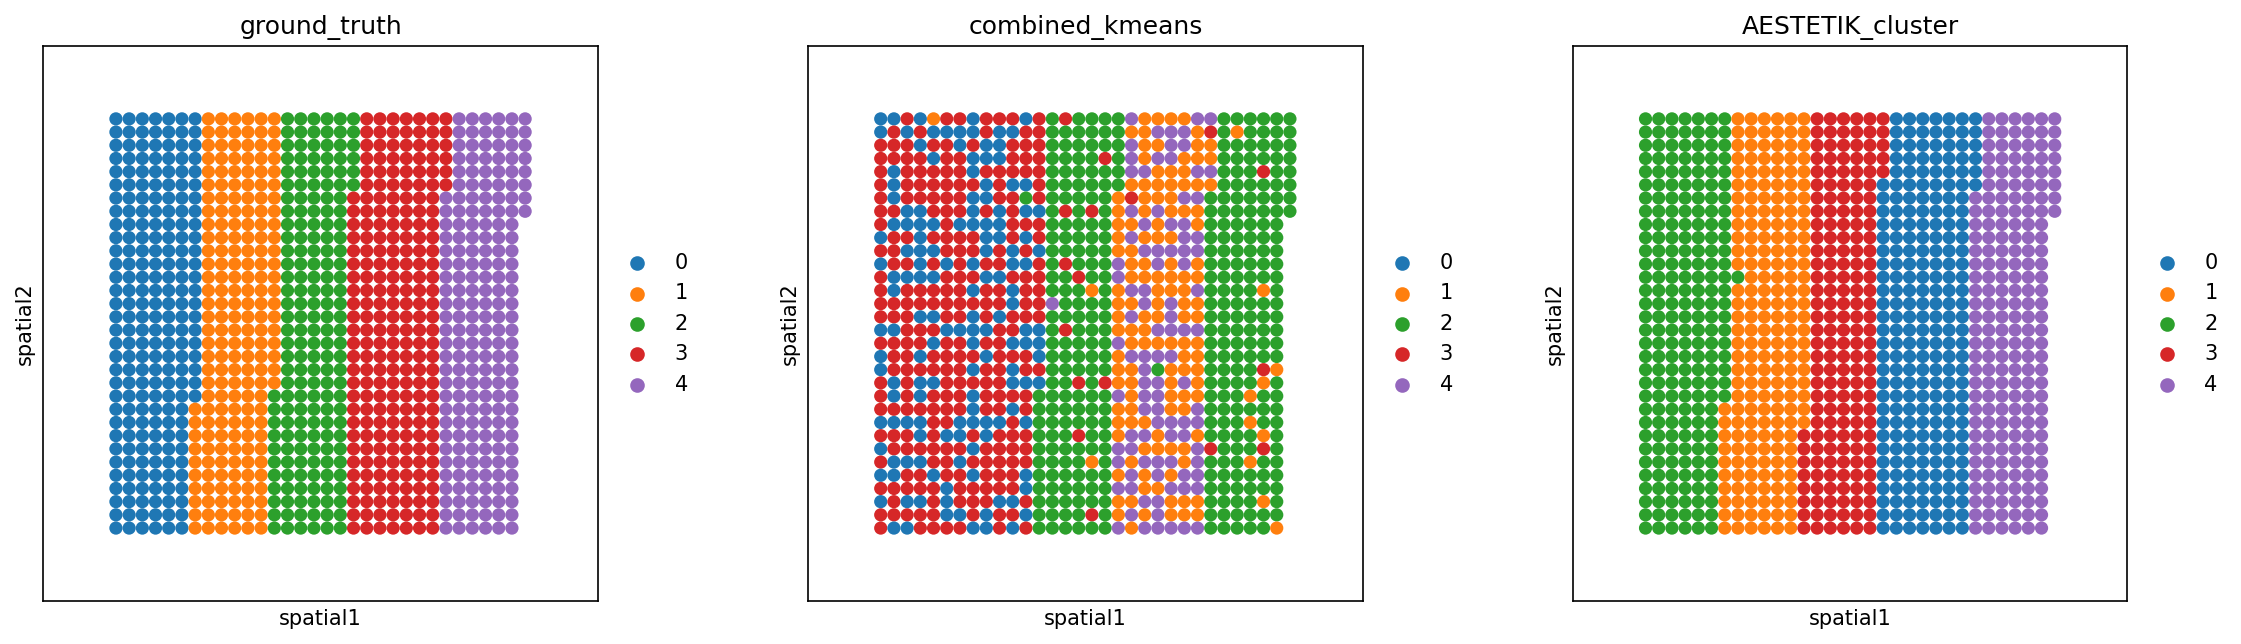

In [17]:
sq.pl.spatial_scatter(adata, color=["ground_truth",
                         "combined_kmeans",
                         "AESTETIK_cluster"], 
                      ncols=5,
                      wspace=0,
                      dpi=150,
                      size=0.5)

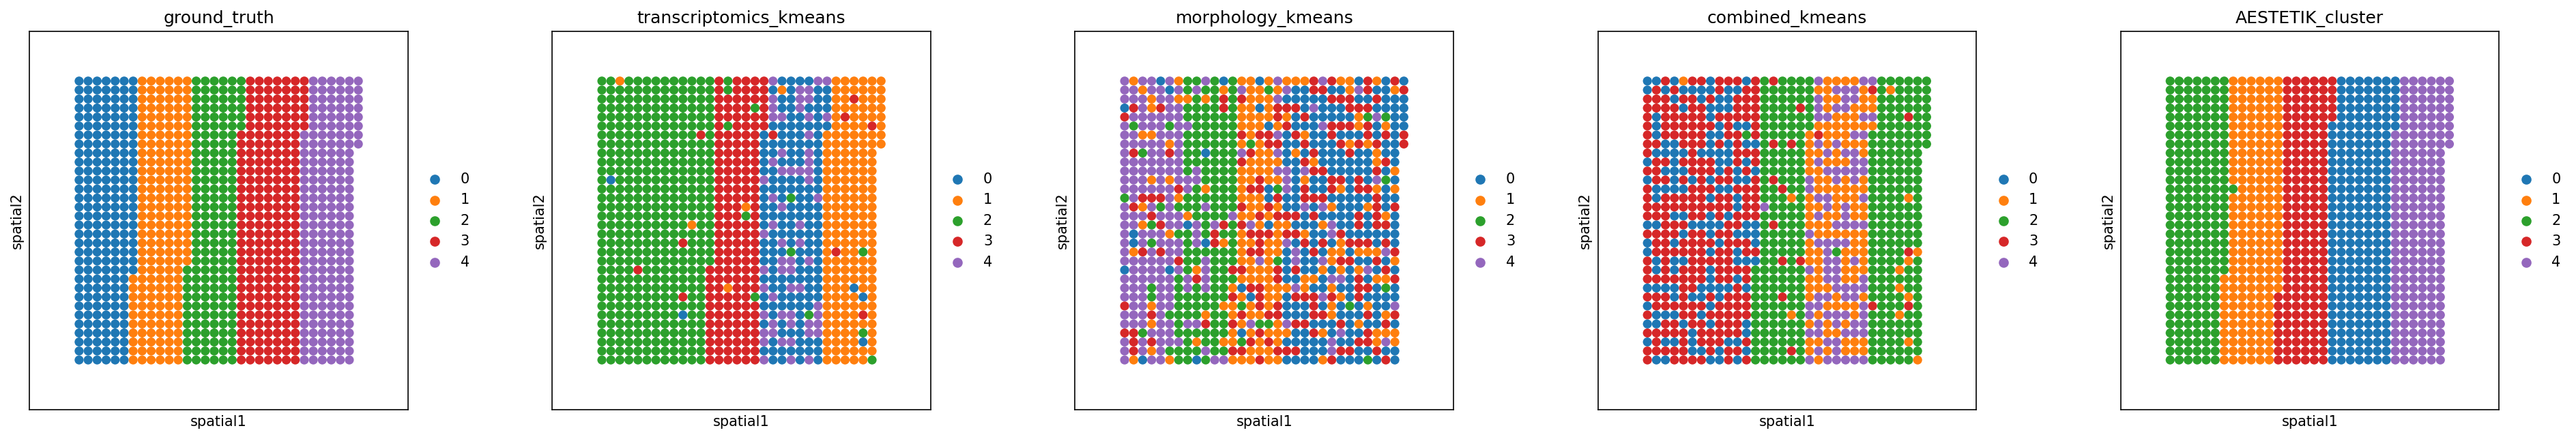

In [18]:
sq.pl.spatial_scatter(adata, color=["ground_truth",
                                    "transcriptomics_kmeans",
                                     "morphology_kmeans",
                                     "combined_kmeans",
                                     "AESTETIK_cluster"], 
                                  ncols=5,
                                  wspace=0,
                                  dpi=150,
                                  size=0.5,
                                  save="AESTETIK_clustering.png"
                     )